# Dataset Analysis

PXD030304 from the [Pan-cancer proteomic map of 949 human cell lines](https://www.cell.com/cancer-cell/fulltext/S1535-6108(22)00274-4?dgcid=raven_jbs_aip_email). Dataset is available [here](https://www.ebi.ac.uk/pride/archive/projects/PXD030304).

In [107]:
dataset_name = "PXD030304"

In [108]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from helper import load_tsv_with_condition

In [109]:
file_path = Path("../data/raw/PXD030304.tsv")
df = load_tsv_with_condition(file_path)

In [110]:
print(f"{df.shape[0]} samples across {df.shape[1]-1} proteins.")
print(f"Number of unique conditions {len(df["condition"].unique())}.")

2012 samples across 8754 proteins.
Number of unique conditions 950.


## A.1. Filtering dataset

It has a control cell line, the HEK293T. We will dropped it. And will have 949 samples after all.

### Drop control cell line

In [111]:
df_no_control = df[df["condition"] != "HEK293T"]
print(f"{df_no_control.shape[0]} samples across {df_no_control.shape[1]-1} proteins.")
df_no_control.to_csv("../data/processed/PXD030304/PXD030304_no_control.csv", index=True) # no control cell line

949 samples across 8754 proteins.


In [112]:
# sanity check
df_aux = pd.read_csv("../data/processed/PXD030304/PXD030304_no_control.csv", index_col=0)
assert df_aux.shape[0] == df_no_control.shape[0] and df_aux.shape[1]-1 == df_no_control.shape[1]-1

### Filter multi peptide proteins

Filter multi peptide proteins (6692) described in the paper.

In [113]:
excel_df = pd.read_excel("../data/raw/Supplementary Table 2.xlsx", sheet_name=1)

In [114]:
excel_df.shape

(950, 6693)

In [115]:
excel_df

,Table S2 Protein matrix. Related to Figure 1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 6683,Unnamed: 6684,Unnamed: 6685,Unnamed: 6686,Unnamed: 6687,Unnamed: 6688,Unnamed: 6689,Unnamed: 6690,Unnamed: 6691,Unnamed: 6692
0,Project_Identifier,P37108;SRP14_HUMAN,Q96JP5;ZFP91_HUMAN,Q9Y4H2;IRS2_HUMAN,P36578;RL4_HUMAN,Q6SPF0;SAMD1_HUMAN,O76031;CLPX_HUMAN,Q8WUQ7;CATIN_HUMAN,A6NIH7;U119B_HUMAN,Q9BTD8;RBM42_HUMAN,...,P33151;CADH5_HUMAN,Q5EBL4;RIPL1_HUMAN,P49715;CEBPA_HUMAN,Q5TA45;INT11_HUMAN,O14924;RGS12_HUMAN,Q7Z3B1;NEGR1_HUMAN,O60669;MOT2_HUMAN,Q13571;LAPM5_HUMAN,Q96JM2;ZN462_HUMAN,P35558;PCKGC_HUMAN
1,SIDM00018;K052,7.10955,3.41494,NaN,7.86661,3.89547,4.19666,NaN,NaN,3.19088,...,NaN,NaN,3.90064,2.63998,NaN,NaN,NaN,NaN,NaN,NaN
2,SIDM00023;TE-12,6.82802,4.14346,2.23781,7.62878,3.19811,4.60902,NaN,2.47059,3.69535,...,NaN,NaN,NaN,3.19608,NaN,NaN,NaN,NaN,NaN,NaN
3,SIDM00040;TMK-1,7.01426,4.19987,2.44055,8.12459,NaN,4.76881,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SIDM00041;STS-0421,5.28591,3.35789,NaN,7.97268,NaN,4.52092,NaN,NaN,2.73088,...,NaN,NaN,NaN,2.79023,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,SIDM01248;CGTH-W-1,6.31631,4.86933,NaN,7.62433,3.92689,4.47212,NaN,NaN,3.48464,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
946,SIDM01251;H9,6.23087,2.71686,NaN,7.23503,3.42065,4.7178,NaN,NaN,3.62514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
947,SIDM01259;GR-ST,7.00407,NaN,NaN,7.5815,NaN,4.59082,NaN,NaN,3.3296,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
948,SIDM01261;YMB-1-E,6.76532,3.75777,NaN,7.24133,3.05477,4.7403,NaN,NaN,2.56268,...,NaN,3.43213,NaN,2.46381,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
proteins_to_filter = excel_df.iloc[0]

In [117]:
proteins_to_filter = proteins_to_filter[1:6993]

In [118]:
proteins_to_filter

Unnamed: 1       P37108;SRP14_HUMAN
Unnamed: 2       Q96JP5;ZFP91_HUMAN
Unnamed: 3        Q9Y4H2;IRS2_HUMAN
Unnamed: 4         P36578;RL4_HUMAN
Unnamed: 5       Q6SPF0;SAMD1_HUMAN
                        ...        
Unnamed: 6688    Q7Z3B1;NEGR1_HUMAN
Unnamed: 6689     O60669;MOT2_HUMAN
Unnamed: 6690    Q13571;LAPM5_HUMAN
Unnamed: 6691    Q96JM2;ZN462_HUMAN
Unnamed: 6692    P35558;PCKGC_HUMAN
Name: 0, Length: 6692, dtype: object

In [119]:
type(proteins_to_filter)

pandas.core.series.Series

In [120]:
name_proteins_to_filter = proteins_to_filter.apply(lambda x: re.search(r'^([^;]+);', x).group(1))

In [121]:
name_proteins_to_filter

Unnamed: 1       P37108
Unnamed: 2       Q96JP5
Unnamed: 3       Q9Y4H2
Unnamed: 4       P36578
Unnamed: 5       Q6SPF0
                  ...  
Unnamed: 6688    Q7Z3B1
Unnamed: 6689    O60669
Unnamed: 6690    Q13571
Unnamed: 6691    Q96JM2
Unnamed: 6692    P35558
Name: 0, Length: 6692, dtype: object

In [122]:
not_present = ['P10636', 'P05386', 'P01854', 'P69905', 'P07205', 'P08758', 'P00441', 'Q06830', 'P00915', 'Q04695', 'P02533', 'P99999', 'P20930', 'P04040', 'P08729', 'P05787', 'P02768', 'P13645', 'Q7Z3Y7', 'P09211', 'P06396', 'P19012', 'P13646', 'Q9UKY3', 'P35900', 'P07339', 'Q9C075', 'O95678', 'P15559', 'Q9H2K0', 'Q99717', 'P62937', 'Q9NSB2', 'P01880', 'Q6KB66', 'P08779', 'P08311', 'P13647', 'P78386', 'Q8N1N4', 'P61626', 'Q8NC44', 'P00918', 'P10599', 'P19013', 'P11309', 'P56134', 'Q5MY95', 'Q9P2N6', 'P55957', 'Q86Y13', 'Q96S82', 'O00762', 'Q8N7X0', 'Q7Z794', 'Q5FBB7', 'Q9P2P6', 'Q92903', 'P57071', 'P16083', 'P68871', 'Q15843', 'P05413', 'P00167', 'P63313', 'Q06033', 'P01857', 'P06732', 'P02144', 'P01344', 'P02538', 'P13284', 'Q96E14', 'Q96RR4', 'P61769', 'Q53S33', 'Q9Y2I7', 'Q4KMG0', 'Q9UK55', 'P63165', 'Q96JB1', 'P30711', 'Q86Y46', 'P0C870', 'Q9HB66', 'Q7Z4R8']
print(len(not_present))

86


In [123]:
# number proteins to filter
print(len(name_proteins_to_filter))

6692


In [124]:
common_proteins = df_no_control.columns.intersection(name_proteins_to_filter)
df_no_control_multi_peptide_proteins = df_no_control[common_proteins]
df_no_control_multi_peptide_proteins["condition"] = df_no_control["condition"]

/var/folders/xh/sc83qkdn4452g73ky21k64rw0000gn/T/ipykernel_4671/2572879366.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_control_multi_peptide_proteins["condition"] = df_no_control["condition"]


It turns out we only have 6606 proteins in common between the proteins described in the paper with more than one peptide and the PXD030304 dataset we have available.

In [125]:
df_no_control_multi_peptide_proteins.shape

(949, 6607)

In [126]:
assert df_no_control_multi_peptide_proteins.shape[0] == df_no_control.shape[0] and df_no_control_multi_peptide_proteins.shape[1] == 6606 + 1

In [127]:
df_no_control_multi_peptide_proteins.to_csv("../data/processed/PXD030304/PXD030304_no_control_multi_peptide.csv", index=True)

In [128]:
# sanity check
df_aux = pd.read_csv("../data/processed/PXD030304/PXD030304_no_control_multi_peptide.csv", index_col=0)
assert df_aux.shape[0] == df_no_control_multi_peptide_proteins.shape[0] and df_aux.shape[1] == df_no_control_multi_peptide_proteins.shape[1]
assert "condition" in df_aux.columns

## A.2. Analysis

### A.2.1. Value distribution

In [129]:
# plt.hist(df_no_control_multi_peptide_proteins.drop(columns=["condition"]).values, bins=100)
# plt.xlabel("Protein intensity")
# plt.ylabel("Frequency")
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.show()

Mean value per protein

In [130]:
mean_protein_intensity = df_no_control_multi_peptide_proteins.drop(columns=["condition"]).mean()

In [131]:
mean_protein_intensity

protein
A0A0B4J1V0    5.704761
A0A0U1RRL7    6.105082
A0AV96        5.796524
A0AVT1        5.930318
A0FGR8        6.079841
                ...   
Q9Y6X5        5.728393
Q9Y6X8        5.307524
Q9Y6X9        5.523826
Q9Y6Y0        5.429938
Q9Y6Y8        5.974861
Length: 6606, dtype: float64

In [132]:
# plt.boxplot()
# plt.show()

### A.2.2. Missingness per protein

In [133]:
missing_counts = df_no_control_multi_peptide_proteins.drop(columns=["condition"]).isna().sum(axis=0)

In [134]:
missing_counts

protein
A0A0B4J1V0    920
A0A0U1RRL7    396
A0AV96        463
A0AVT1          1
A0FGR8          2
             ... 
Q9Y6X5         60
Q9Y6X8        288
Q9Y6X9          4
Q9Y6Y0        401
Q9Y6Y8          9
Length: 6606, dtype: int64

In [135]:
missing_pct = (missing_counts / df_no_control_multi_peptide_proteins.shape[0]) * 100
print(missing_pct.describe())
mean = missing_pct.mean()
median = missing_pct.median()
print(median)

count    6606.000000
mean       23.997279
std        28.288033
min         0.000000
25%         0.526870
50%        10.115911
75%        42.676502
max        98.735511
dtype: float64
10.1159114857745


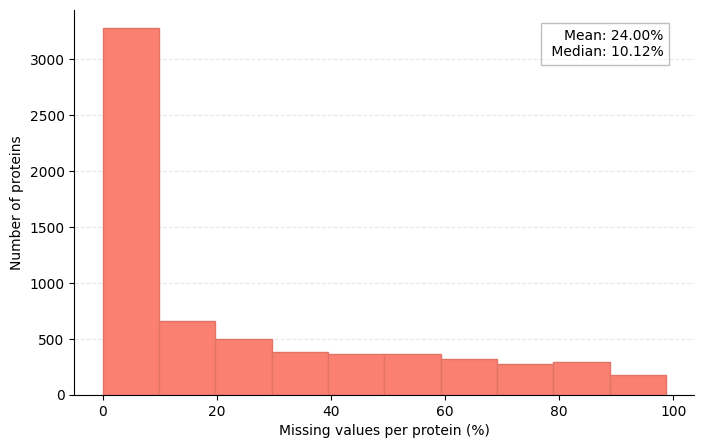

In [136]:
import matplotlib.colors as mcolors

def darker(color, factor=0.8):
    r, g, b = mcolors.to_rgb(color)
    return (r*factor, g*factor, b*factor)

color = "salmon"

plt.figure(figsize=(8,5))
plt.hist(missing_pct, bins=10, color=color, edgecolor=darker(color,0.90), linewidth=1)
plt.ylabel("Frequency")
plt.text(0.95, 0.95, f'Mean: {mean:.2f}%\n Median: {median:.2f}%', 
         horizontalalignment='right', verticalalignment='top', 
         transform=plt.gca().transAxes,
         fontsize=10, bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
ax = plt.gca()
plt.grid(axis='y', alpha=0.3, linestyle="--")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
plt.xlabel('Missing values per protein (%)')
plt.ylabel('Number of proteins')
plt.savefig("plots/PXD030304_missingness_per_protein_versionA.png")
plt.show()

How many proteins have missingness of 0? #todo

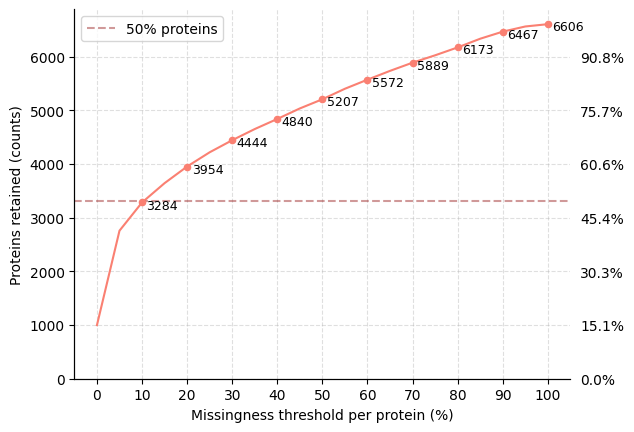

In [137]:
thresholds = range(0,101,5)
proteins_retained = np.array([(missing_pct <= t).sum() for t in thresholds])

plt.plot(thresholds, proteins_retained, color="salmon")
plt.xlabel("Missingness threshold per protein (%)")
plt.ylabel("Proteins retained")
dot_thresholds = np.arange(10, 101, 10)

for t in dot_thresholds:
    
    idx = np.where(thresholds == t)[0][0]
    prot = proteins_retained[idx]

    plt.scatter(t, prot, zorder=3, color="salmon", s=20)
    plt.text(t + 1, prot - 50, f"{prot}", fontsize=9, ha="left", va="center")

ax = plt.gca()
plt.grid(alpha=0.4, linestyle="--")
ax.set_axisbelow(True)

plt.axhline(
    df_no_control_multi_peptide_proteins.shape[1]/2, 
    linestyle="--", 
    alpha=0.4, 
    color="darkred",
    label="50% proteins"
)
plt.legend()
plt.xticks(np.arange(0, 101, 10))

total_proteins = len(missing_pct)

# primary axis
yticks = np.arange(0, proteins_retained.max(), 1000)
ax.set_yticks(yticks)
ax.set_ylabel("Proteins retained (counts)")

# secondary axis
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

pct_labels = [f"{y/total_proteins*100:.1f}%" for y in yticks]
ax2.set_yticks(yticks)
ax2.set_yticklabels(pct_labels)
# ax2.set_ylabel("%")

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

ax2.tick_params(right=False)

plt.savefig("plots/PXD030304/PXD030304_no_control_multi_peptide_proteins_retained_vs_missingness_threshold.png")
plt.show()

### A.2.3. Missingness per sample

In [138]:
sample_missing_counts = df_no_control_multi_peptide_proteins.drop(columns=["condition"]).isna().sum(axis=1)
sample_missing_counts

sample_accession
PXD030304-Sample-1      1437
PXD030304-Sample-10     1389
PXD030304-Sample-100    1660
PXD030304-Sample-101    1883
PXD030304-Sample-102    1623
                        ... 
PXD030304-Sample-95     2040
PXD030304-Sample-96     1211
PXD030304-Sample-97     1826
PXD030304-Sample-98     1449
PXD030304-Sample-99     1189
Length: 949, dtype: int64

In [139]:
sample_missing_pct = (sample_missing_counts / df_no_control_multi_peptide_proteins.shape[1]) * 100
sample_missing_pct.describe()

count    949.000000
mean      23.993647
std        4.474044
min       14.863024
25%       20.992886
50%       23.248070
75%       26.290298
max       57.620705
dtype: float64

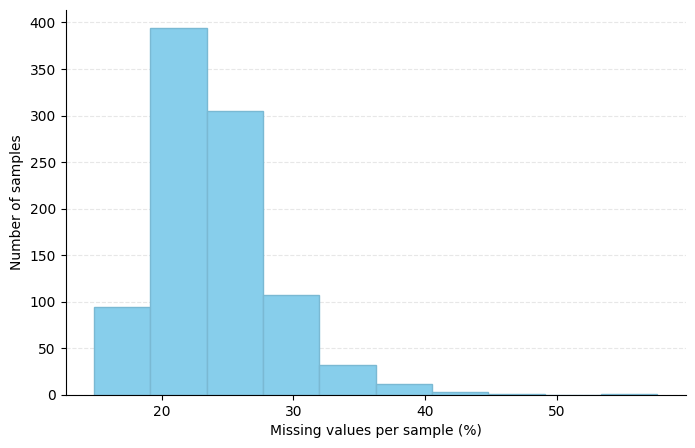

In [140]:
import matplotlib.colors as mcolors

def darker(color, factor=0.8):
    r, g, b = mcolors.to_rgb(color)
    return (r*factor, g*factor, b*factor)

color = "skyblue"

plt.figure(figsize=(8,5))
plt.hist(sample_missing_pct, bins=10, color=color, edgecolor=darker(color,0.90), linewidth=1)
plt.ylabel("Frequency")
ax = plt.gca()
plt.grid(axis='y', alpha=0.3, linestyle="--")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
plt.xlabel('Missing values per sample (%)')
plt.ylabel('Number of samples')
plt.savefig("plots/PXD030304_missingness_per_sample.png")
plt.show()

### A.2.4. Batch effects

In [141]:
#todo

### A.2.5. Condition

In [142]:
#todo

## Continuing A.1. Filtering dataset

So, after having a more concrete understanding of the protein missingness (A.2.2.), we can remove proteins that have a missingness higher than a certain threshold.

Discard proteins with >**50**% missing values.
- Still ensures at least half of the samples have measurements.
- 50% aligns nicely with the 75th percentile (~43%), meaning we remove the worst tail.

In [143]:
missing_pct

protein
A0A0B4J1V0    96.944152
A0A0U1RRL7    41.728135
A0AV96        48.788198
A0AVT1         0.105374
A0FGR8         0.210748
                ...    
Q9Y6X5         6.322445
Q9Y6X8        30.347734
Q9Y6X9         0.421496
Q9Y6Y0        42.255005
Q9Y6Y8         0.948367
Length: 6606, dtype: float64

In [144]:
mask = missing_pct <= 50
df_condition = df_no_control_multi_peptide_proteins["condition"]
df_aux = df_no_control_multi_peptide_proteins.drop(columns=["condition"])
df_no_control_multi_peptide_proteins_50pct = df_aux[df_aux.columns[mask]]
df_no_control_multi_peptide_proteins_50pct["condition"] = df_condition
df_no_control_multi_peptide_proteins_50pct.to_csv("../data/processed/PXD030304/PXD030304_no_control_multi_peptide_50pct.csv", index=True)

/var/folders/xh/sc83qkdn4452g73ky21k64rw0000gn/T/ipykernel_4671/2128867238.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_control_multi_peptide_proteins_50pct["condition"] = df_condition


In [145]:
df_no_control_multi_peptide_proteins_50pct.shape

(949, 5208)

In [146]:
read_df = pd.read_csv("../data/processed/PXD030304/PXD030304_no_control_multi_peptide_50pct.csv", index_col=0)
assert read_df.shape[0] == df_no_control_multi_peptide_proteins.shape[0] and read_df.shape[1] == df_no_control_multi_peptide_proteins_50pct.shape[1]

### Continuing A.2.1. Value distribution

Now, with the final dataset.

In [147]:
mean_protein_intensity = df_no_control_multi_peptide_proteins_50pct.drop(columns=["condition"]).mean()

In [148]:
mean_protein_intensity

protein
A0A0U1RRL7    6.105082
A0AV96        5.796524
A0AVT1        5.930318
A0FGR8        6.079841
A0MZ66        5.836194
                ...   
Q9Y6X5        5.728393
Q9Y6X8        5.307524
Q9Y6X9        5.523826
Q9Y6Y0        5.429938
Q9Y6Y8        5.974861
Length: 5207, dtype: float64

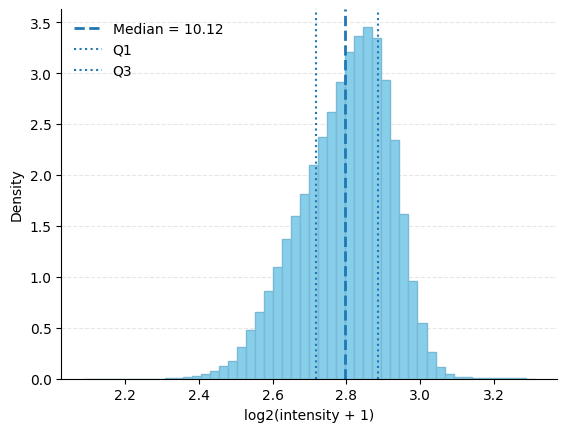

In [149]:
def darker(color, factor=0.8):
    r, g, b = mcolors.to_rgb(color)
    return (r*factor, g*factor, b*factor)

color = "skyblue"

log_intensities = np.log2(df_no_control_multi_peptide_proteins_50pct.drop(columns=["condition"]).values.flatten() + 1)  # flatten all protein intensities
log_intensities = log_intensities[~np.isnan(log_intensities)]

plt.hist(
    log_intensities, 
    bins=50, 
    color=color, 
    edgecolor=darker(color,0.90), 
    linewidth=1,
    density=True,
)
plt.axvline(np.mean(log_intensities), linestyle="--", linewidth=2, label=f"Median = {median:.2f}")
plt.axvline(np.percentile(log_intensities, 25), linestyle=":", linewidth=1.5, label="Q1")
plt.axvline(np.percentile(log_intensities, 75), linestyle=":", linewidth=1.5, label="Q3")

plt.xlabel("log2(intensity + 1)")
plt.ylabel("Density")
# plt.title("Distribution of protein intensities")

ax = plt.gca()
plt.grid(axis='y', alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(frameon=False)

plt.savefig("plots/PXD030304/PXD030304_no_control_multi_peptide_proteins_50pct_protein_intensities.png")
plt.show()